from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.sql.window import *
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("E-commerce") \
    .master("spark://192.168.137.1:7077") \
    .config("spark.executor.instances", "2") \
    .config("spark.executor.cores", "2") \
    .config("spark.executor.memory", "6g") \
    .config("spark.driver.memory", "6g") \
    .config("spark.driver.maxResultSize", "2g") \
    .config("spark.sql.shuffle.partitions", "64") \
    .config("spark.default.parallelism", "4") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.autoBroadcastJoinThreshold", str(10 * 1024 * 1024)) \
    .config("spark.memory.fraction", "0.7") \
    .config("spark.memory.storageFraction", "0.3") \
    .config("spark.sql.files.maxPartitionBytes", "64MB") \
    .getOrCreate()



In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("E-commerce") \
    .master("local[*]") \
    .config("spark.driver.memory", "6g") \
    .config("spark.driver.maxResultSize", "2g") \
    .config("spark.sql.shuffle.partitions", "64") \
    .config("spark.default.parallelism", "4") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.autoBroadcastJoinThreshold", str(10 * 1024 * 1024)) \
    .config("spark.memory.fraction", "0.7") \
    .config("spark.memory.storageFraction", "0.3") \
    .config("spark.sql.files.maxPartitionBytes", "64MB") \
    .getOrCreate()


In [ ]:
full_orders = spark.read \
    .option("header", True) \
    .option("compression", "gzip") \
    .csv(r"D:\VS CODE\.vscode\PDC_SEM_PROJECT\datasets\full_orders_compressed")


# adding frequently used columns

In [ ]:
full_orders = full_orders.withColumn("order_month", date_format("order_purchase_timestamp", "yyyy-MM"))

In [ ]:
# Repartition the full_orders DataFrame for better parallelism and performance
full_orders = full_orders.repartition(8, "order_id")

In [ ]:
product_popularity = spark.read.csv(r"D:\VS CODE\.vscode\PDC_SEM_PROJECT\insights\product_popularity.csv", header=True, inferSchema=True)
seller_performance = spark.read.csv(r"D:\VS CODE\.vscode\PDC_SEM_PROJECT\insights\seller_performance.csv", header=True, inferSchema=True)
customer_retention = spark.read.csv(r"D:\VS CODE\.vscode\PDC_SEM_PROJECT\insights\customer_retention.csv", header=True, inferSchema=True)
customer_spending = spark.read.csv(r"D:\VS CODE\.vscode\PDC_SEM_PROJECT\insights\customer_spending.csv", header=True, inferSchema=True)

In [ ]:
product_popularity.show(5)
seller_performance.show(5)
customer_retention.show(5)
customer_spending.show(5)

+--------------------+----------+------------------+---------+--------------------+----------------+-----------------+
|        product_name|total_sold|     total_revenue|avg_price|      unique_sellers|avg_review_score|price_variability|
+--------------------+----------+------------------+---------+--------------------+----------------+-----------------+
|Compact Gadget #4571|     85348| 6067329.499998108|    71.09|['955fee9216a65b6...|            4.01|             3.19|
|  Premium Item #5033|     81048| 4583192.809999049|    56.55|['1f50f920176fa81...|            3.83|            25.03|
|  Compact Item #2444|     77770|6831677.2099974165|    87.84|['4a3ca9315b744ce...|             4.0|              4.1|
|Compact Gadget #6901|     60248| 3280533.130000288|    54.45|['1f50f920176fa81...|            4.25|             4.37|
|  Sleek Gadget #7626|     59437| 8233515.030000735|   138.53|['a1043bafd471dff...|            4.18|            16.79|
+--------------------+----------+---------------

# Cacheing

In [ ]:
full_orders.cache()

DataFrame[customer_id: string, order_id: string, seller_id: string, product_id: string, order_status: string, order_purchase_timestamp: string, order_approved_at: string, order_delivered_carrier_date: string, order_delivered_customer_date: string, order_estimated_delivery_date: string, order_item_id: string, shipping_limit_date: string, price: string, freight_value: string, product_name_lenght: string, product_description_lenght: string, product_photos_qty: string, product_weight_g: string, product_length_cm: string, product_height_cm: string, product_width_cm: string, product_category_name: string, product_size_category: string, product_name: string, seller_zip_code_prefix: string, seller_city: string, seller_state: string, customer_unique_id: string, customer_zip_code_prefix: string, customer_city: string, customer_state: string, geolocation_zip_code_prefix: string, geolocation_lat: string, geolocation_lng: string, geolocation_city: string, geolocation_state: string, review_id: strin

# Checking and Filling NULLs

In [ ]:
full_orders = full_orders.fillna('none')

In [ ]:
from pyspark.sql.functions import col, sum as spark_sum

null_counts = full_orders.select([
    spark_sum(col(c).isNull().cast("int")).alias(c) for c in full_orders.columns
])
null_counts.show()


+-----------+--------+---------+----------+------------+------------------------+-----------------+----------------------------+-----------------------------+-----------------------------+-------------+-------------------+-----+-------------+-------------------+--------------------------+------------------+----------------+-----------------+-----------------+----------------+---------------------+---------------------+------------+----------------------+-----------+------------+------------------+------------------------+-------------+--------------+---------------------------+---------------+---------------+----------------+-----------------+---------+------------+--------------------+----------------------+--------------------+-----------------------+------------------+------------+--------------------+-------------+------------+-----------+-------------+----------------+-----------+--------------+----------------+-----------+
|customer_id|order_id|seller_id|product_id|order_status|o

In [ ]:
full_orders.printSchema()

root
 |-- customer_id: string (nullable = false)
 |-- order_id: string (nullable = false)
 |-- seller_id: string (nullable = false)
 |-- product_id: string (nullable = false)
 |-- order_status: string (nullable = false)
 |-- order_purchase_timestamp: string (nullable = false)
 |-- order_approved_at: string (nullable = false)
 |-- order_delivered_carrier_date: string (nullable = false)
 |-- order_delivered_customer_date: string (nullable = false)
 |-- order_estimated_delivery_date: string (nullable = false)
 |-- order_item_id: string (nullable = false)
 |-- shipping_limit_date: string (nullable = false)
 |-- price: string (nullable = false)
 |-- freight_value: string (nullable = false)
 |-- product_name_lenght: string (nullable = false)
 |-- product_description_lenght: string (nullable = false)
 |-- product_photos_qty: string (nullable = false)
 |-- product_weight_g: string (nullable = false)
 |-- product_length_cm: string (nullable = false)
 |-- product_height_cm: string (nullable = fa

In [ ]:
full_orders.show(5)

+--------------------+--------------------+--------------------+--------------------+------------+------------------------+-----------------+----------------------------+-----------------------------+-----------------------------+-------------+--------------------+-----+-------------+-------------------+--------------------------+------------------+----------------+-----------------+-----------------+----------------+---------------------+---------------------+------------------+----------------------+-----------+------------+--------------------+------------------------+-------------+--------------+---------------------------+-------------------+-------------------+----------------+-----------------+--------------------+------------+--------------------+----------------------+--------------------+-----------------------+------------------+-------------+--------------------+-------------+------------+-----------+-------------+----------------+-----------+--------------+----------------

In [ ]:
order_details = spark.read.csv(r'D:\VS CODE\.vscode\PDC_SEM_PROJECT\datasets\order_with_details.csv',header=True, inferSchema=True)

In [ ]:
order_details.printSchema()
order_details.show(5)

root
 |-- customer_id: string (nullable = true)
 |-- order_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: date (nullable = true)
 |-- order_delivered_carrier_date: date (nullable = true)
 |-- order_delivered_customer_date: date (nullable = true)
 |-- order_estimated_delivery_date: date (nullable = true)
 |-- order_item_id: double (nullable = true)
 |-- product_id: string (nullable = true)
 |-- seller_id: string (nullable = true)
 |-- shipping_limit_date: timestamp (nullable = true)
 |-- price: double (nullable = true)
 |-- freight_value: double (nullable = true)
 |-- payment_sequential: double (nullable = true)
 |-- payment_type: string (nullable = true)
 |-- payment_installments: double (nullable = true)
 |-- payment_value: double (nullable = true)
 |-- customer_unique_id: string (nullable = true)
 |-- customer_zip_code_prefix: integer (nullable = true)
 |-- customer_city: stri

# Analysis and Ploting

# Monthly Revenue Growth

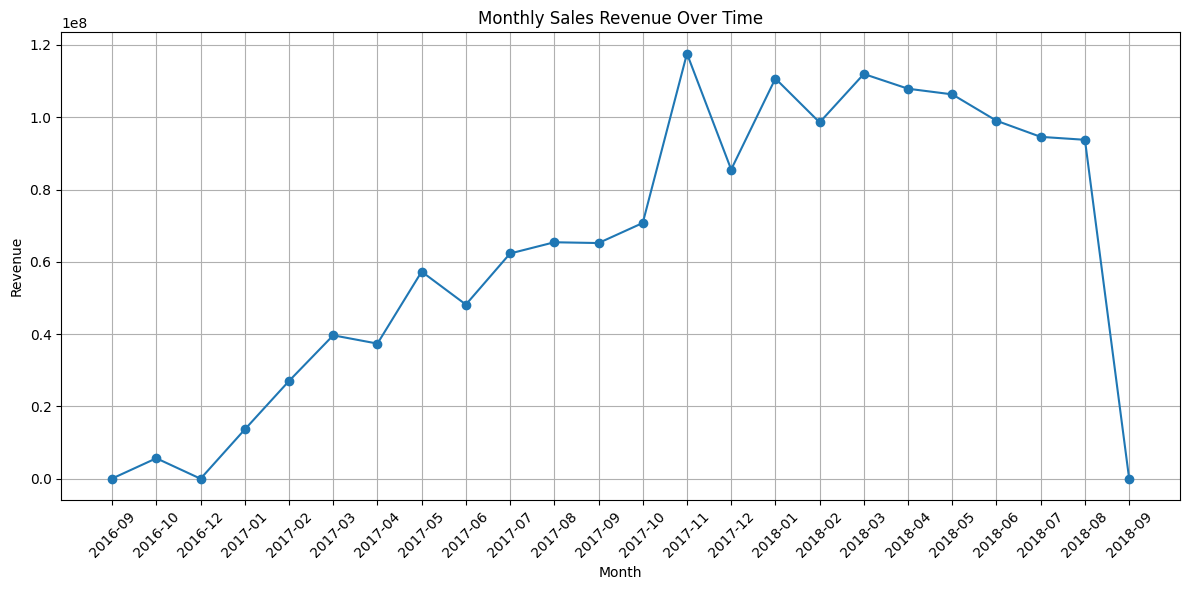

In [ ]:
monthly_sales = full_orders.groupBy("order_month") \
                  .agg(sum("order_revenue").alias("monthly_revenue")) \
                  .orderBy("order_month")


sales_pd = monthly_sales.toPandas()


plt.figure(figsize=(12, 6))
plt.plot(sales_pd['order_month'], sales_pd['monthly_revenue'], marker='o', linestyle='-')
plt.title("Monthly Sales Revenue Over Time")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# Revenue by State  

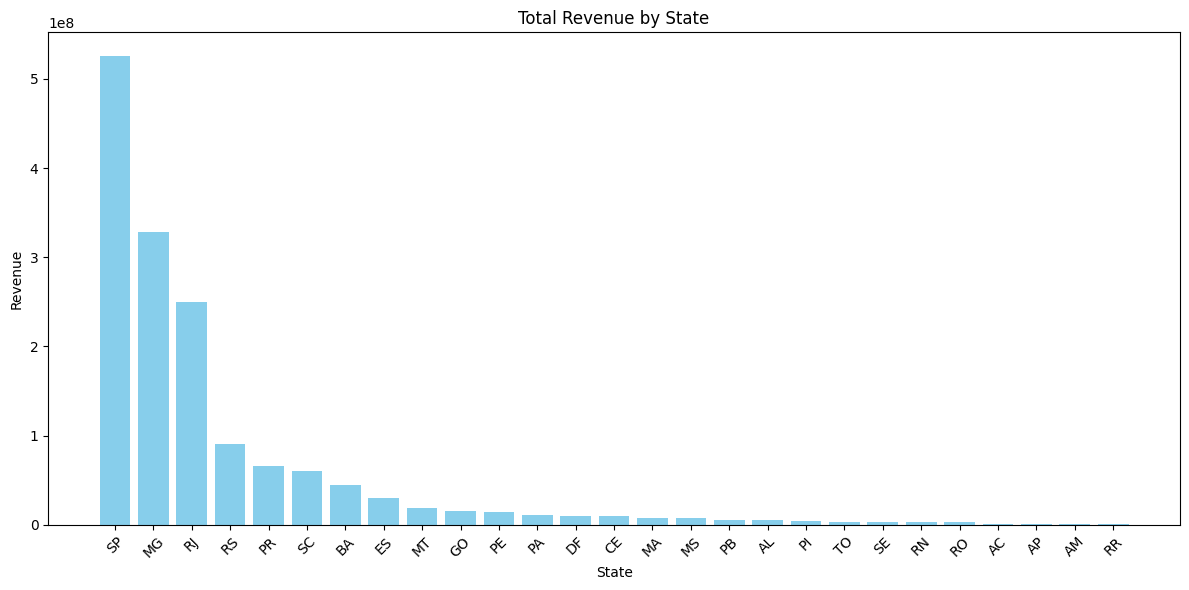

In [ ]:
revenue_by_state = full_orders.groupBy("customer_state") \
                              .agg(sum("order_revenue").alias("total_revenue")) \
                              .orderBy(col("total_revenue").desc())


revenue_by_state_pd = revenue_by_state.toPandas()


plt.figure(figsize=(12, 6))
plt.bar(revenue_by_state_pd['customer_state'], revenue_by_state_pd['total_revenue'], color='skyblue')
plt.title("Total Revenue by State")
plt.xlabel("State")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Revenue By product category (top 15)

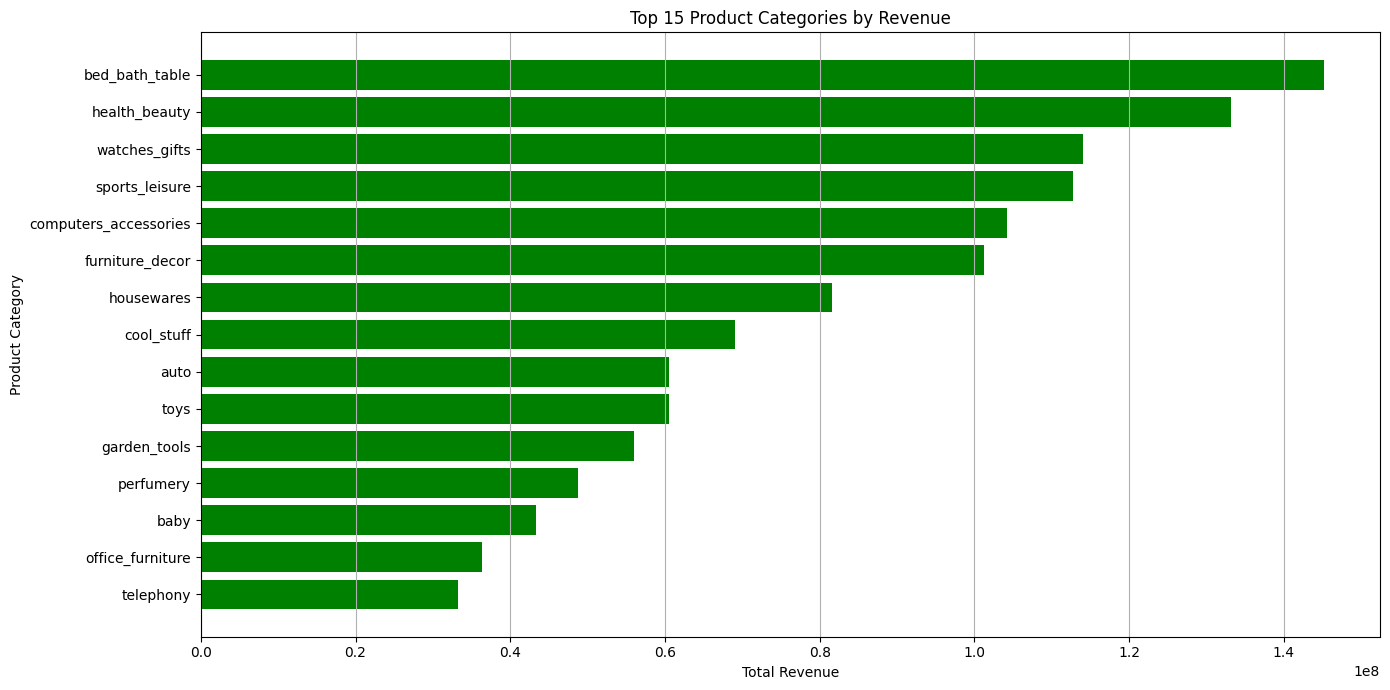

In [ ]:
revenue_by_category = full_orders.dropna(subset=["product_category_name"]) \
                                 .groupBy("product_category_name") \
                                 .agg(sum("order_revenue").alias("total_revenue")) \
                                 .orderBy(col("total_revenue").desc()).limit(15)
top_categories_pd = revenue_by_category.toPandas()

plt.figure(figsize=(14, 7))
plt.barh(top_categories_pd['product_category_name'], top_categories_pd['total_revenue'], color='green')
plt.title("Top 15 Product Categories by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product Category")
plt.gca().invert_yaxis()  # Highest revenue on top
plt.grid(axis='x')
plt.tight_layout()
plt.show()
                                 


# seasonal trends of top product categories

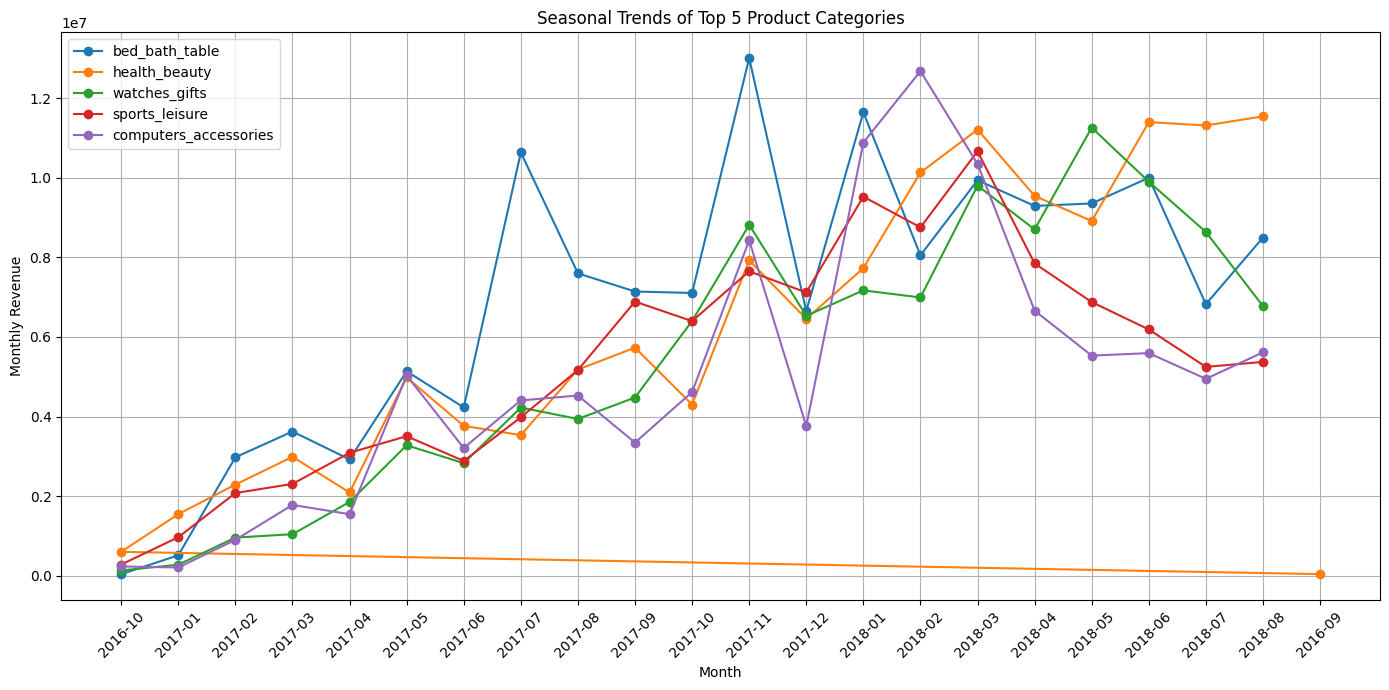

In [ ]:

category_monthly = full_orders.dropna(subset=["product_category_name"]) \
    .groupBy("product_category_name", "order_month") \
    .agg(sum("order_revenue").alias("monthly_revenue")) \
    .orderBy("product_category_name", "order_month")


category_monthly_pd = category_monthly.toPandas()


top5_categories = top_categories_pd['product_category_name'].head(5).tolist()
plt.figure(figsize=(14, 7))
for cat in top5_categories:
    data = category_monthly_pd[category_monthly_pd['product_category_name'] == cat]
    plt.plot(data['order_month'], data['monthly_revenue'], marker='o', label=cat)

plt.title("Seasonal Trends of Top 5 Product Categories")
plt.xlabel("Month")
plt.ylabel("Monthly Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Product Performance

# Product Popularity Based on Review

Best

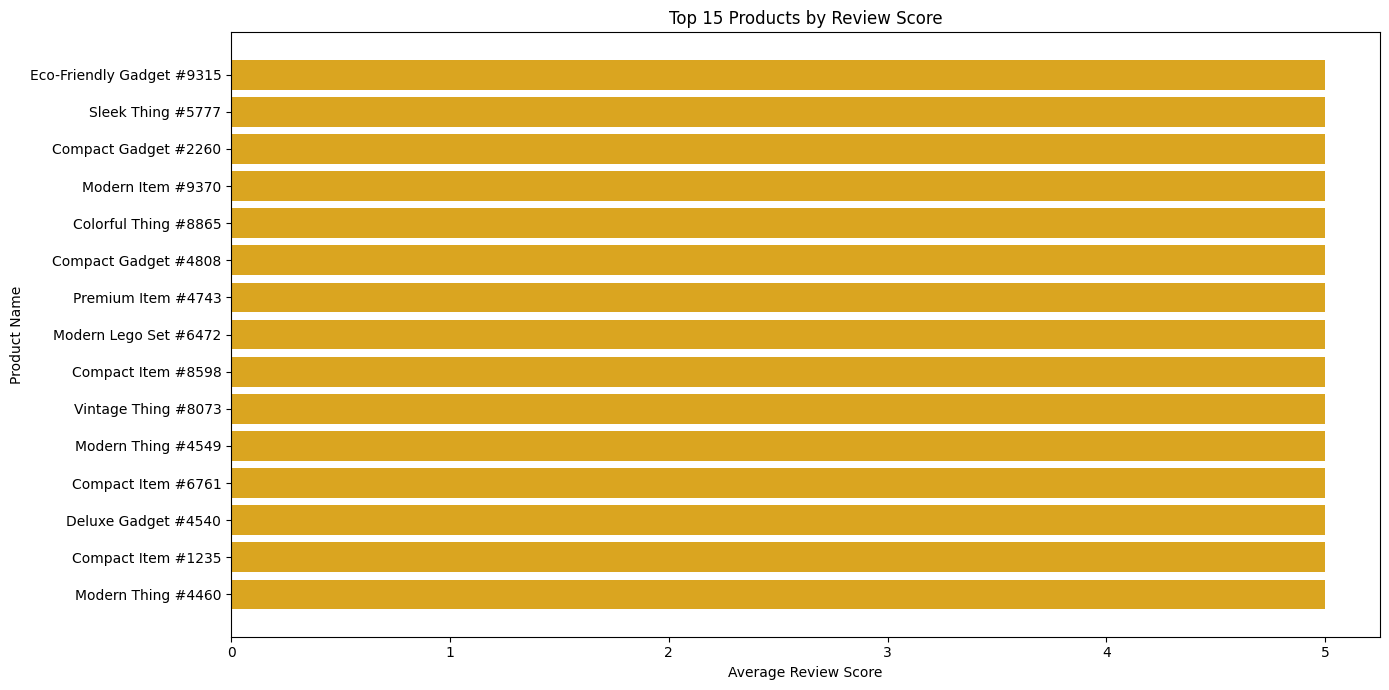

In [ ]:
top_reviewed_products = product_popularity.orderBy(col("avg_review_score").desc()).limit(15)
top_reviewed_products_pd = top_reviewed_products.toPandas()

plt.figure(figsize=(14, 7))
plt.barh(top_reviewed_products_pd["product_name"], top_reviewed_products_pd["avg_review_score"], color='goldenrod')
plt.xlabel("Average Review Score")
plt.ylabel("Product Name")
plt.title("Top 15 Products by Review Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Average

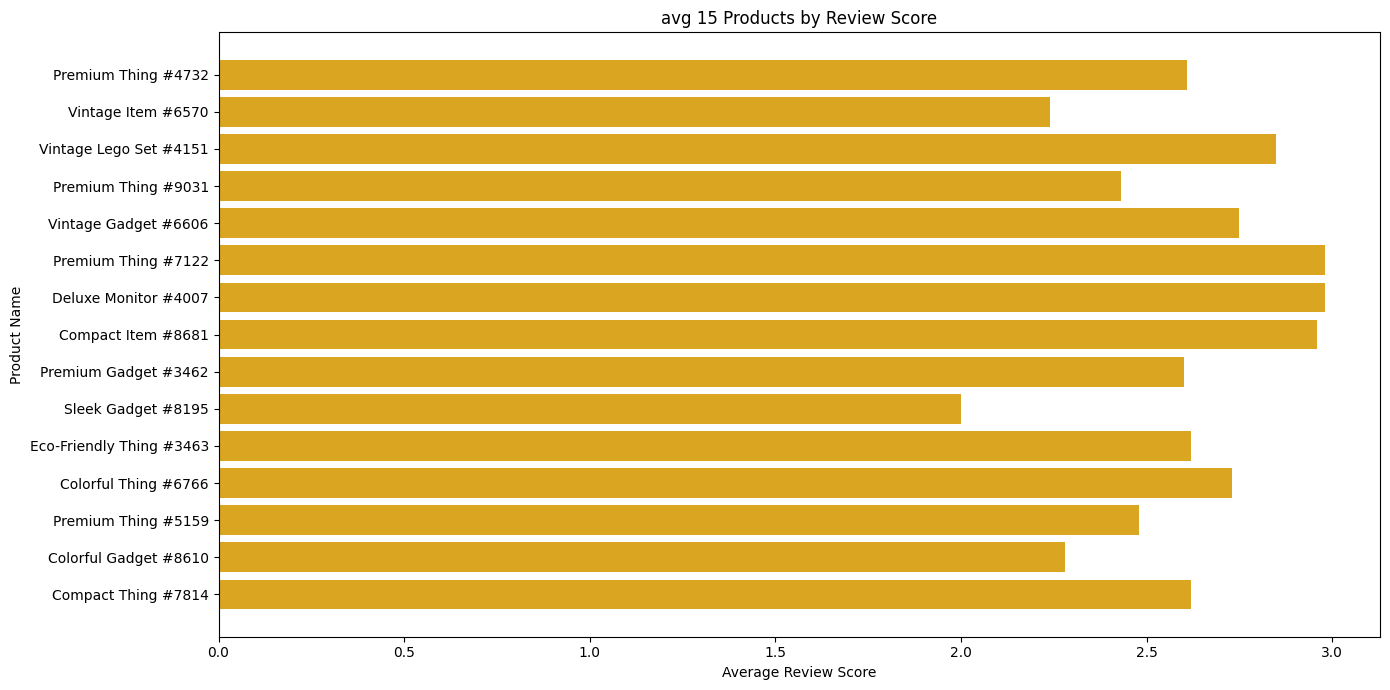

In [ ]:

avg_reviewed_products = product_popularity.filter((col("avg_review_score") >= 2.00) & (col("avg_review_score") <= 3.00)).limit(15)
avg_reviewed_products_pd = avg_reviewed_products.toPandas()

plt.figure(figsize=(14, 7))
plt.barh(avg_reviewed_products_pd["product_name"], avg_reviewed_products_pd["avg_review_score"], color='goldenrod')
plt.xlabel("Average Review Score")
plt.ylabel("Product Name")
plt.title("avg 15 Products by Review Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Least


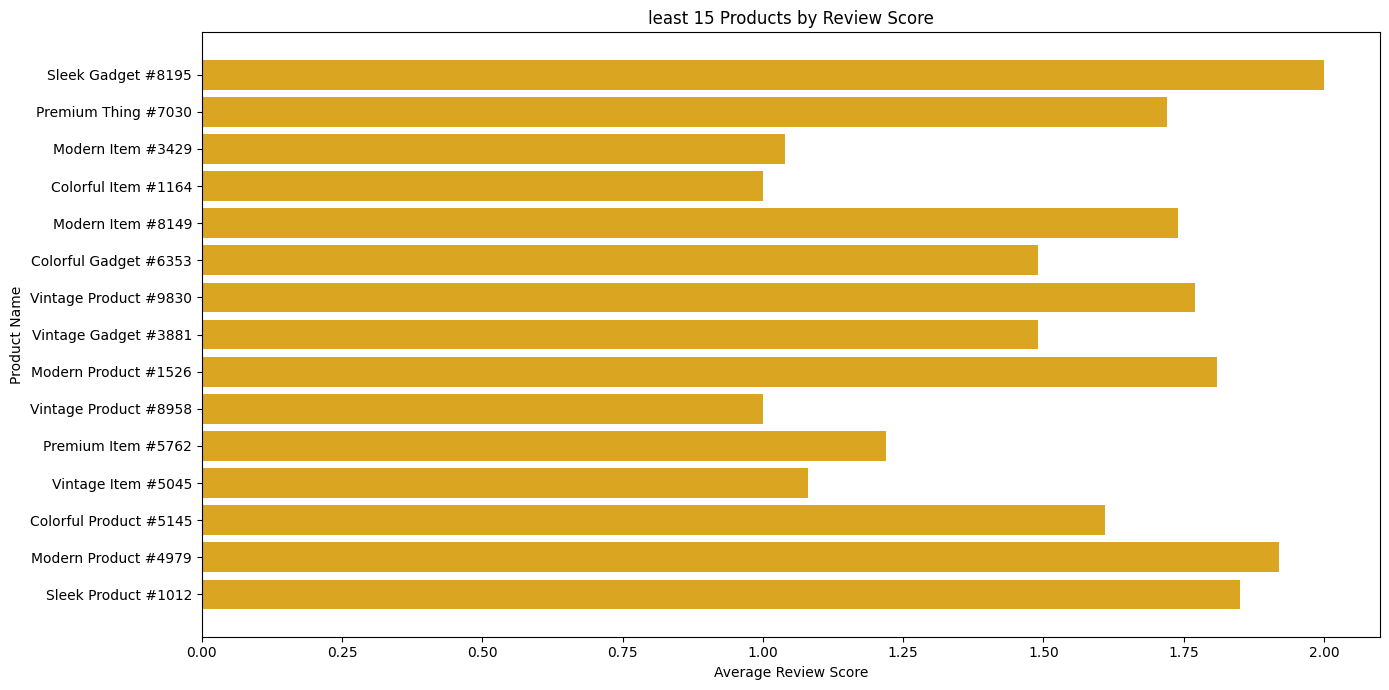

In [ ]:

least_reviewed_products = product_popularity.filter(col("avg_review_score") <= 2.00).limit(15)
least_reviewed_products_pd = least_reviewed_products.toPandas()

plt.figure(figsize=(14, 7))
plt.barh(least_reviewed_products_pd["product_name"], least_reviewed_products_pd["avg_review_score"], color='goldenrod')
plt.xlabel("Average Review Score")
plt.ylabel("Product Name")
plt.title("least 15 Products by Review Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Top Selling 

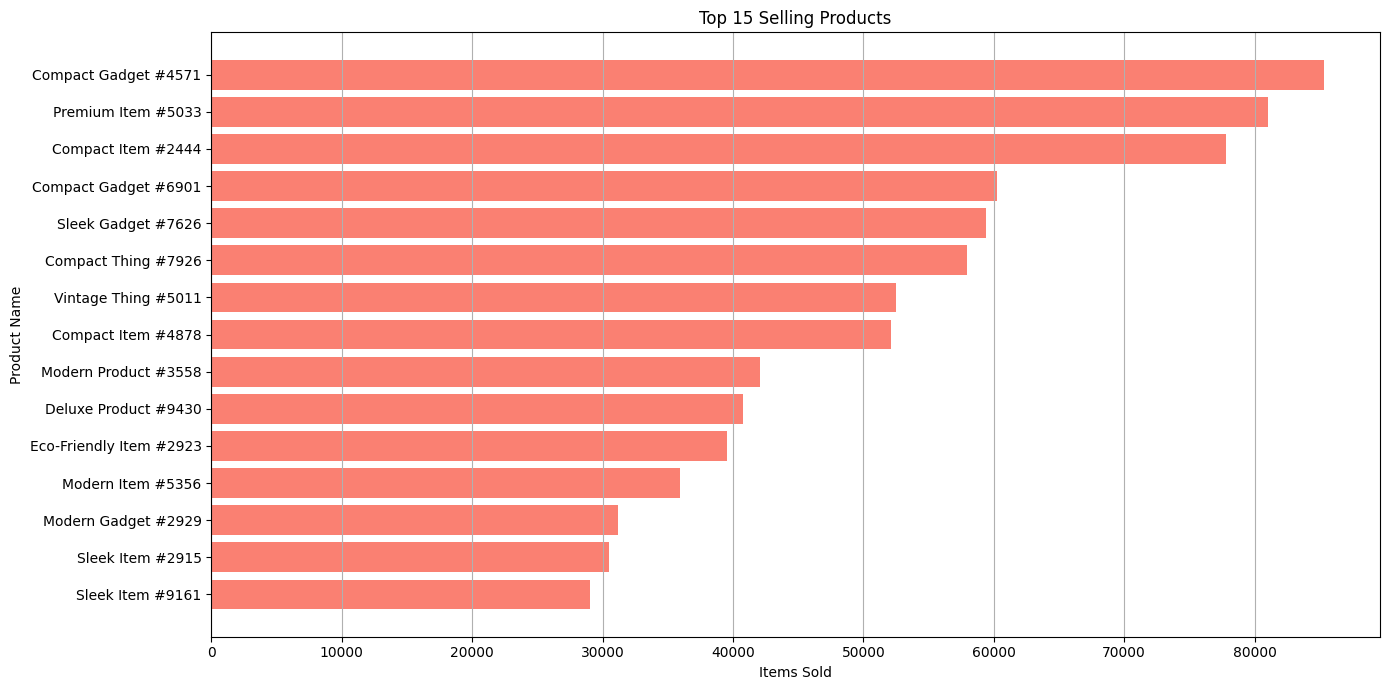

In [ ]:
top_selling_products = product_popularity.orderBy(col("total_sold").desc()).limit(15)

top_selling_products_pd = top_selling_products.toPandas()


plt.figure(figsize=(14, 7))
plt.barh(top_selling_products_pd['product_name'], top_selling_products_pd['total_sold'], color='salmon')
plt.title("Top 15 Selling Products")
plt.xlabel("Items Sold")
plt.ylabel("Product Name")
plt.gca().invert_yaxis()
plt.grid(axis='x')
plt.tight_layout()
plt.show()

# Products by Revenue Contributions


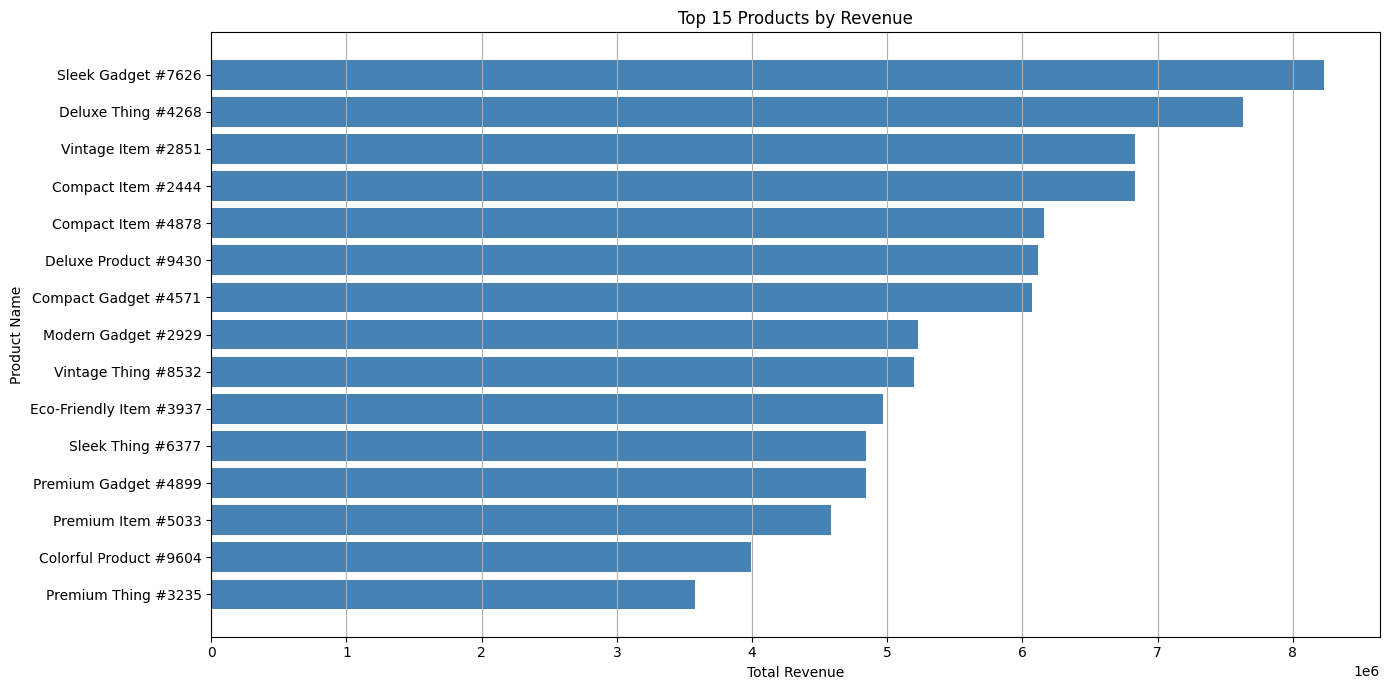

In [ ]:

top_revenue_products = product_popularity.orderBy(col("total_revenue").desc()).limit(15)

product_revenue_pd = top_revenue_products.toPandas()

plt.figure(figsize=(14, 7))
plt.barh(product_revenue_pd['product_name'], product_revenue_pd['total_revenue'], color='steelblue')
plt.title("Top 15 Products by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product Name")
plt.gca().invert_yaxis()
plt.grid(axis='x')
plt.tight_layout()
plt.show()


# order Cancellation based on category

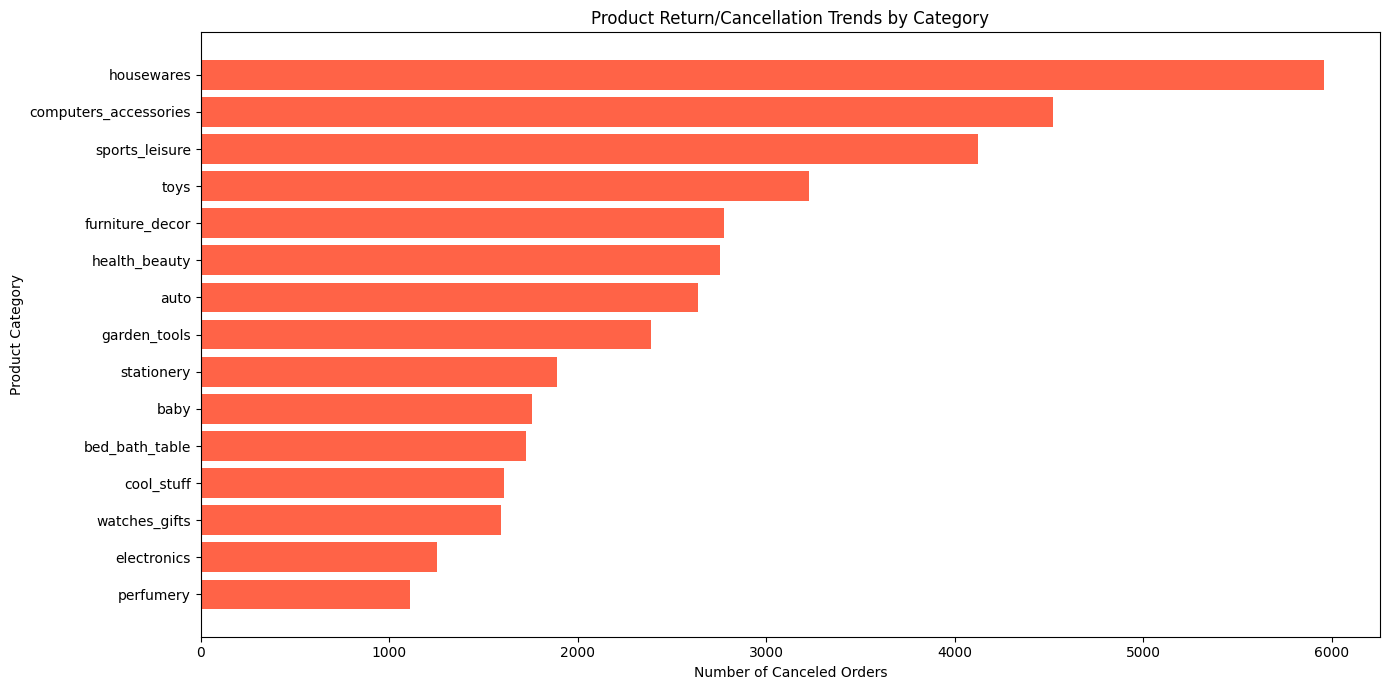

In [ ]:

cancellation_trends = full_orders.filter((col("is_canceled") == "1") & (col("product_category_name").isNotNull())) \
    .groupBy("product_category_name") \
    .agg(count("*").alias("canceled_orders")) \
    .orderBy(col("canceled_orders").desc()).limit(15)

cancellation_trends_pd = cancellation_trends.toPandas()

plt.figure(figsize=(14, 7))
plt.barh(cancellation_trends_pd["product_category_name"], cancellation_trends_pd["canceled_orders"], color='tomato')
plt.xlabel("Number of Canceled Orders")
plt.ylabel("Product Category")
plt.title("Product Return/Cancellation Trends by Category")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Customer Liftime Value (CLV)

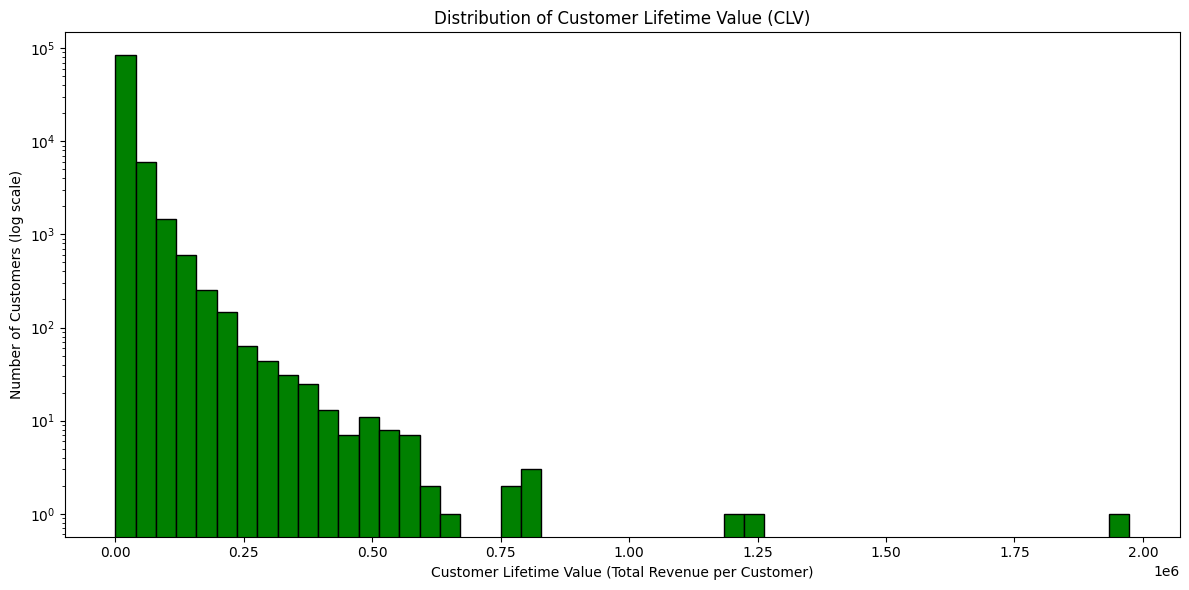

In [ ]:

clv_df = full_orders.groupBy("customer_unique_id") \
    .agg(sum("order_revenue").alias("customer_lifetime_value")) \
    .orderBy(col("customer_lifetime_value").desc())

clv_pd = clv_df.toPandas()

plt.figure(figsize=(12, 6))
plt.hist(clv_pd["customer_lifetime_value"], bins=50, color='green', edgecolor='black', log=True)
plt.title("Distribution of Customer Lifetime Value (CLV)")
plt.xlabel("Customer Lifetime Value (Total Revenue per Customer)")
plt.ylabel("Number of Customers (log scale)")
plt.tight_layout()
plt.show()

# Customer Density By City

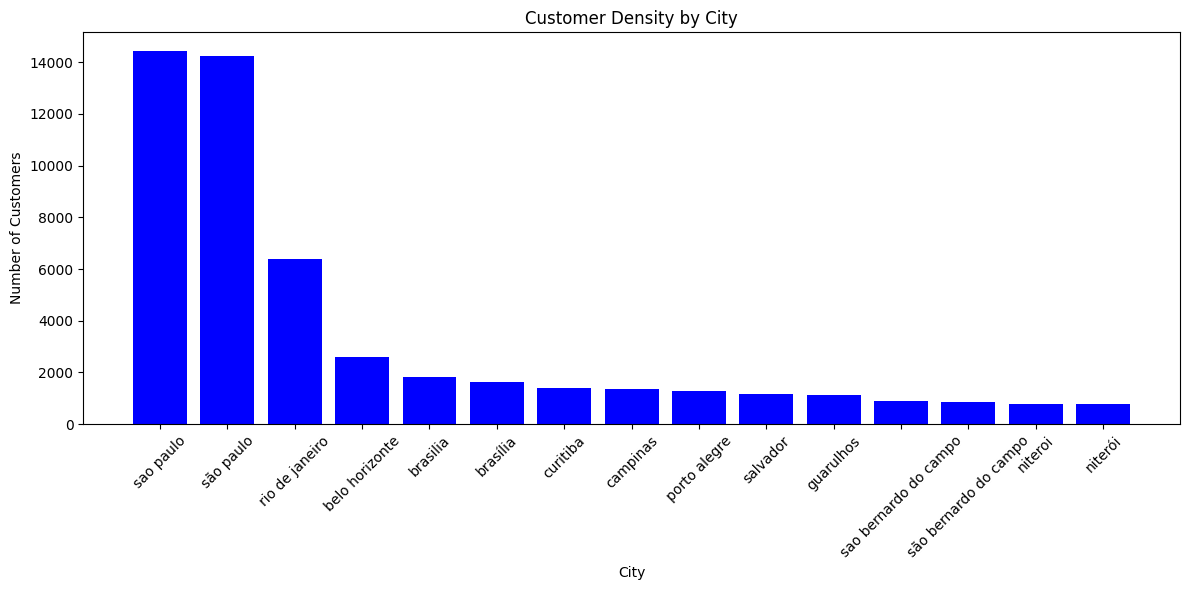

In [ ]:
customer_density = full_orders.filter(col("geolocation_city").isNotNull())
customer_density = customer_density.groupBy("geolocation_city") \
.agg(countDistinct("customer_unique_id").alias("total_customers")) \
.orderBy("total_customers", ascending=False).limit(15)

customer_density_pd = customer_density.toPandas()

plt.figure(figsize=(12, 6))
plt.bar(customer_density_pd["geolocation_city"], customer_density_pd["total_customers"], color='blue')
plt.title("Customer Density by City")
plt.xlabel("City")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Top Spending Customer

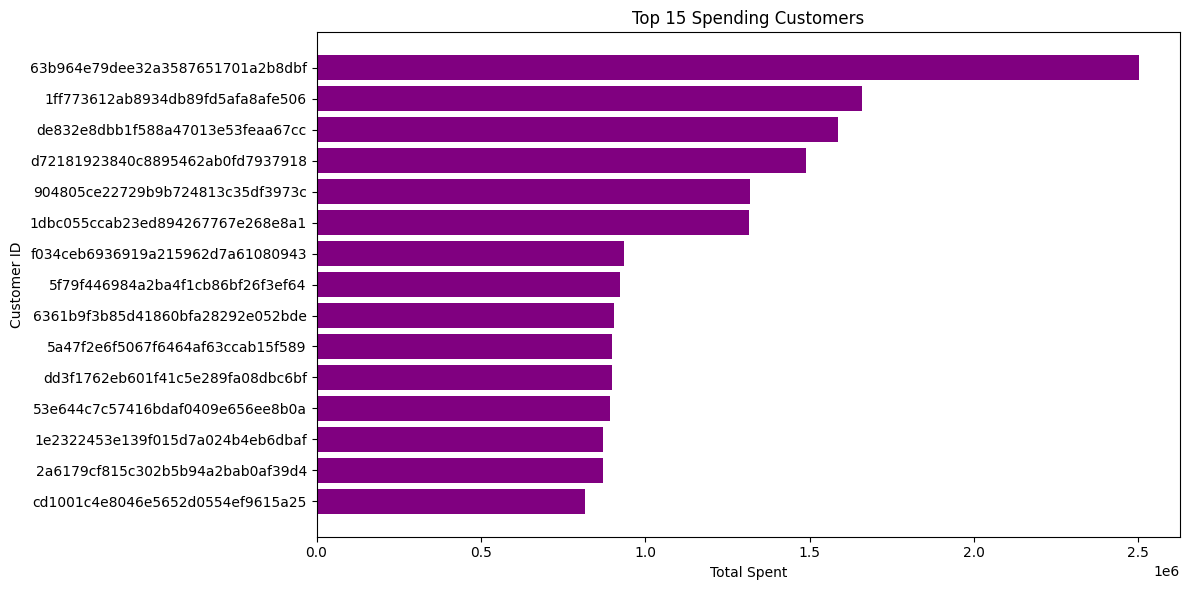

In [ ]:
top_spending_customers = customer_spending.orderBy(col('total_spent').desc()).limit(15)
top_spending_customers_pd = top_spending_customers.toPandas()

plt.figure(figsize=(12, 6))
plt.barh(top_spending_customers_pd['customer_id'], top_spending_customers_pd['total_spent'], color='purple')
plt.title("Top 15 Spending Customers")
plt.xlabel("Total Spent")
plt.ylabel("Customer ID")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Segmented 

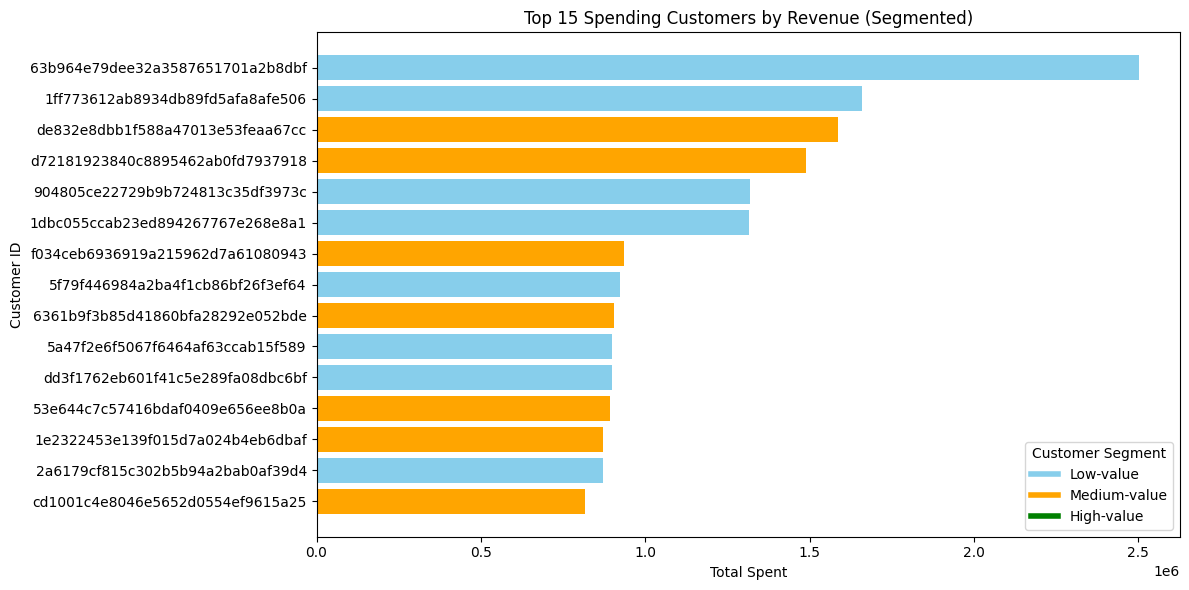

In [ ]:
# Plotting top customers by revenue, colored by customer segment
plt.figure(figsize=(12, 6))
colors = {'low-value': 'skyblue', 'medium-value': 'orange', 'high-value': 'green'}
bar_colors = top_spending_customers_pd['customer_segment'].map(colors).fillna('gray')

plt.barh(
    top_spending_customers_pd['customer_id'],
    top_spending_customers_pd['total_spent'],
    color=bar_colors
)
plt.title("Top 15 Spending Customers by Revenue (Segmented)")
plt.xlabel("Total Spent")
plt.ylabel("Customer ID")
plt.gca().invert_yaxis()
plt.legend(handles=[
    plt.Line2D([0], [0], color='skyblue', lw=4, label='Low-value'),
    plt.Line2D([0], [0], color='orange', lw=4, label='Medium-value'),
    plt.Line2D([0], [0], color='green', lw=4, label='High-value')
], title="Customer Segment")
plt.tight_layout()
plt.show()

# Top Custmomers by number of Orders

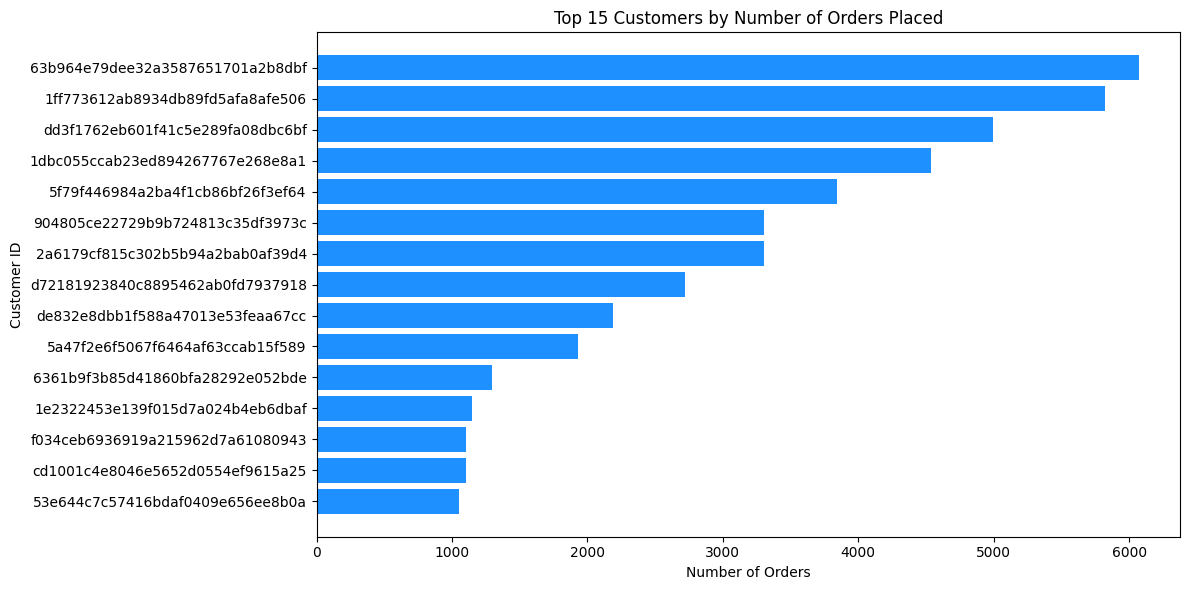

In [ ]:

top_customers_by_orders = top_spending_customers_pd.sort_values(by='total_orders', ascending=False).head(15)

plt.figure(figsize=(12, 6))
plt.barh(top_customers_by_orders['customer_id'], top_customers_by_orders['total_orders'], color='dodgerblue')
plt.title("Top 15 Customers by Number of Orders Placed")
plt.xlabel("Number of Orders")
plt.ylabel("Customer ID")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Popular Payments Methods

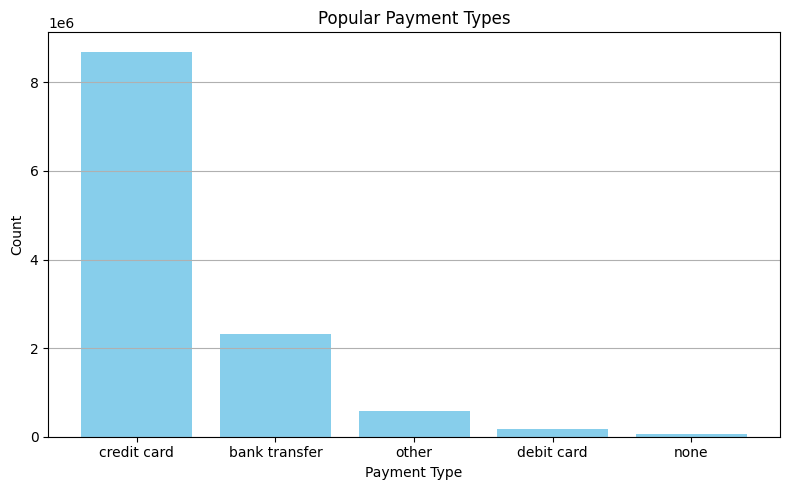

In [ ]:

payment_type_counts = full_orders.groupBy("payment_type") \
    .agg(count("*").alias("count")) \
    .orderBy(col("count").desc())
payment_type_counts_pd = payment_type_counts.toPandas()

plt.figure(figsize=(8, 5))
plt.bar(payment_type_counts_pd["payment_type"], payment_type_counts_pd["count"], color='skyblue')
plt.title("Popular Payment Types")
plt.xlabel("Payment Type")
plt.ylabel("Count")
plt.grid(axis='y')
plt.tight_layout()
plt.show()


# Average number of Installments 

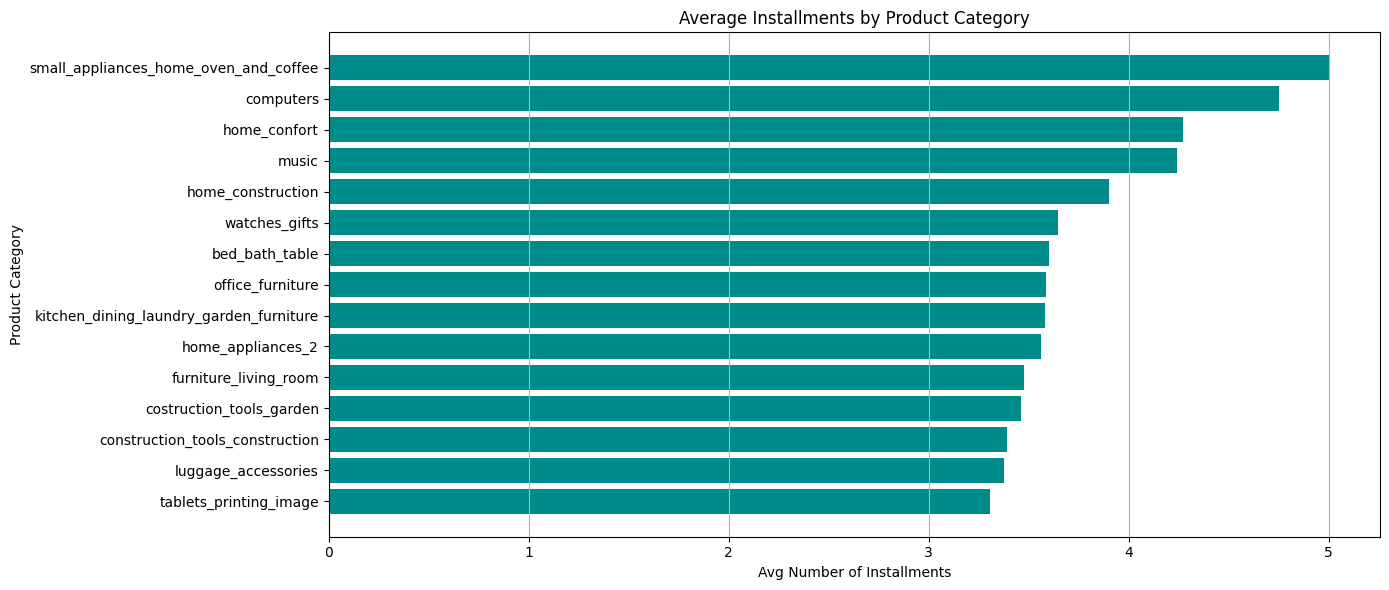

In [ ]:

avg_installments = full_orders.dropna(subset=["product_category_name"]) \
    .groupBy("product_category_name") \
    .agg(avg("payment_installments").alias("avg_installments")) \
    .orderBy(col("avg_installments").desc()) \
    .limit(15)

avg_installments_pd = avg_installments.toPandas()

plt.figure(figsize=(14, 6))
plt.barh(avg_installments_pd["product_category_name"], avg_installments_pd["avg_installments"], color='darkcyan')
plt.title("Average Installments by Product Category")
plt.xlabel("Avg Number of Installments")
plt.ylabel("Product Category")
plt.gca().invert_yaxis()
plt.grid(axis='x')
plt.tight_layout()
plt.show()


# Payment Value Trends

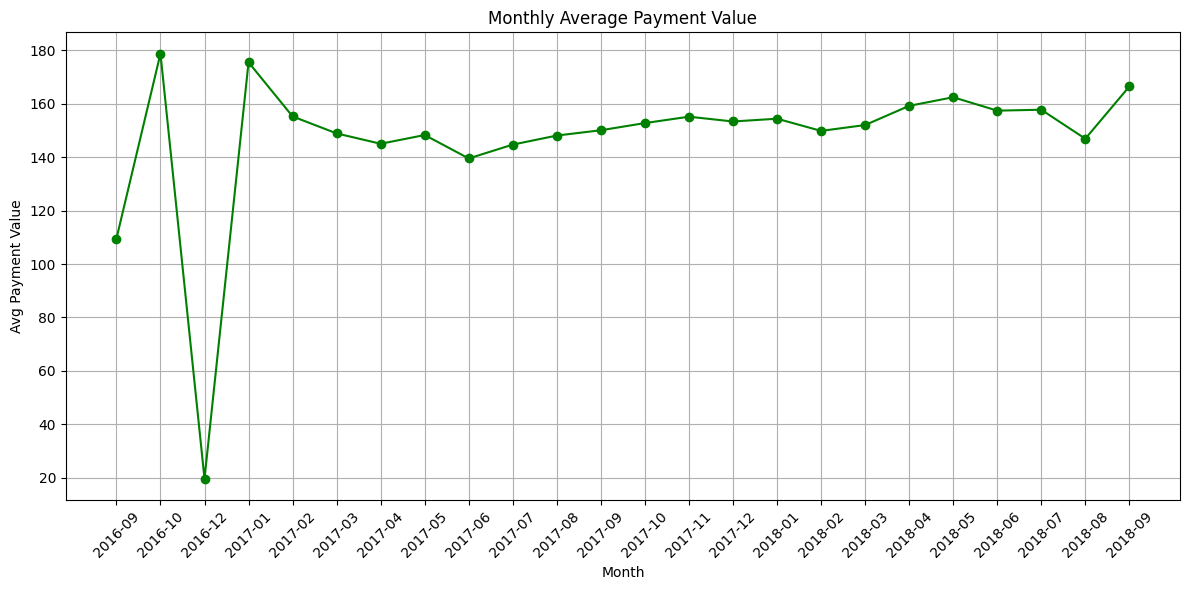

In [ ]:

monthly_payment_trend = full_orders.groupBy("order_month") \
    .agg(avg("payment_value").alias("avg_payment_value")) \
    .orderBy("order_month")
monthly_payment_pd = monthly_payment_trend.toPandas()

plt.figure(figsize=(12, 6))
plt.plot(monthly_payment_pd["order_month"], monthly_payment_pd["avg_payment_value"], marker='o', color='green')
plt.title("Monthly Average Payment Value")
plt.xlabel("Month")
plt.ylabel("Avg Payment Value")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


# Seller Performance

# Top Sellers By Revenue


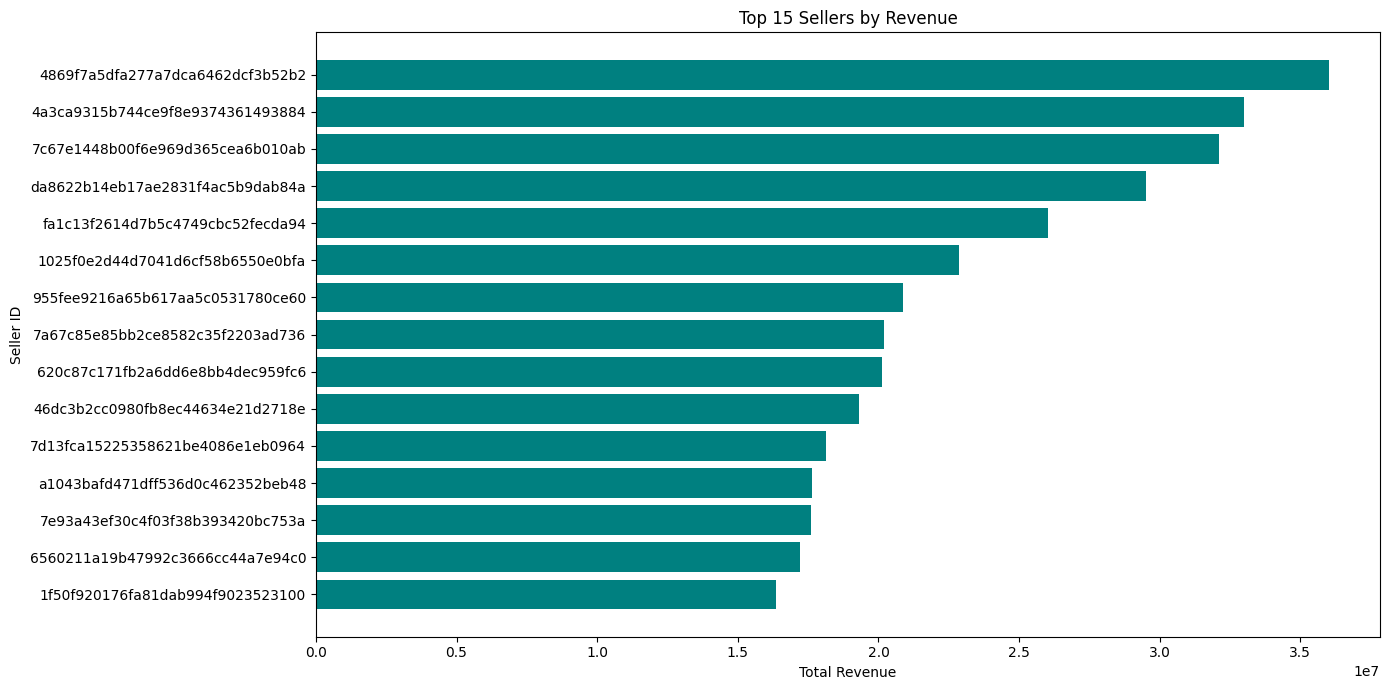

In [ ]:
top_sellers_by_revenue = seller_performance.orderBy(col("total_revenue").desc()).limit(15)
top_sellers_pd = top_sellers_by_revenue.toPandas()

plt.figure(figsize=(14, 7))
plt.barh(top_sellers_pd["seller_id"], top_sellers_pd["total_revenue"], color="teal")
plt.xlabel("Total Revenue")
plt.ylabel("Seller ID")
plt.title("Top 15 Sellers by Revenue")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Top Sellers By Orders 


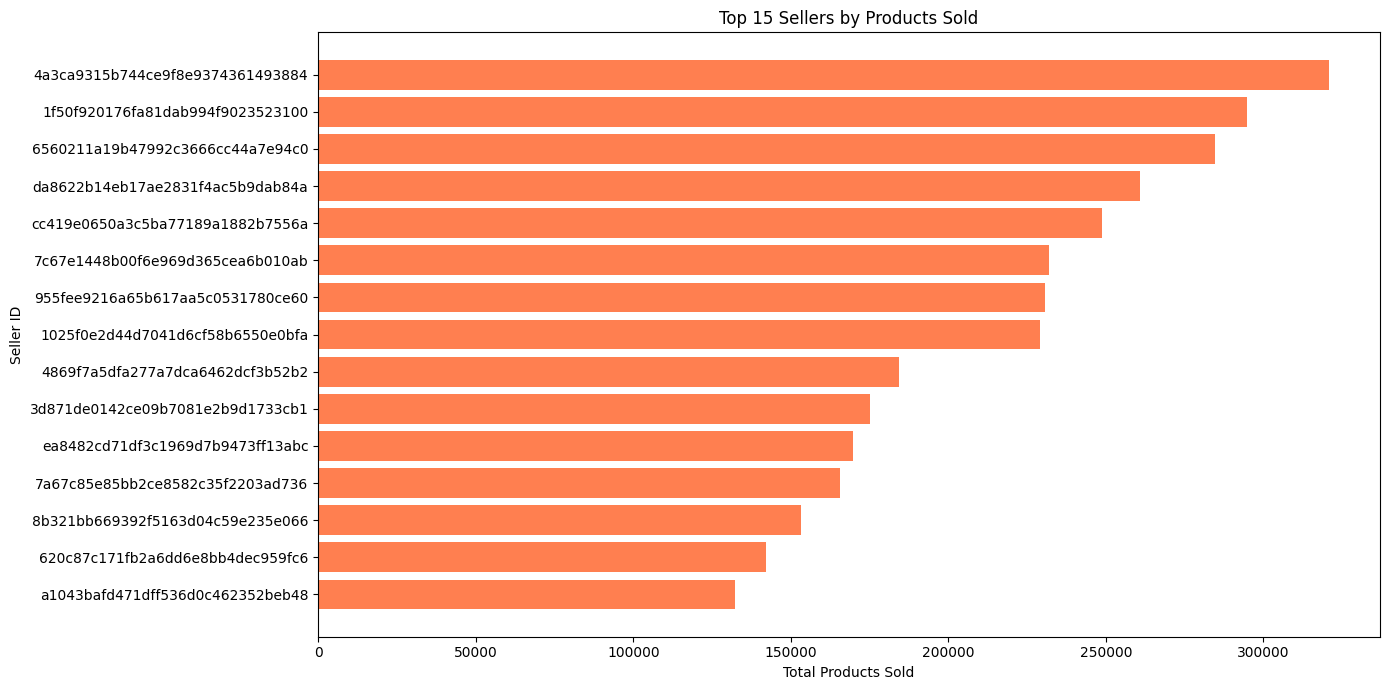

In [ ]:
top_sellers_by_products_sold = seller_performance.orderBy(col("total_orders").desc()).limit(15)
top_sellers_products_pd = top_sellers_by_products_sold.toPandas()

plt.figure(figsize=(14, 7))
plt.barh(top_sellers_products_pd["seller_id"], top_sellers_products_pd["total_orders"], color="coral")
plt.xlabel("Total Products Sold")
plt.ylabel("Seller ID")
plt.title("Top 15 Sellers by Products Sold")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Top Sellers By Review Score

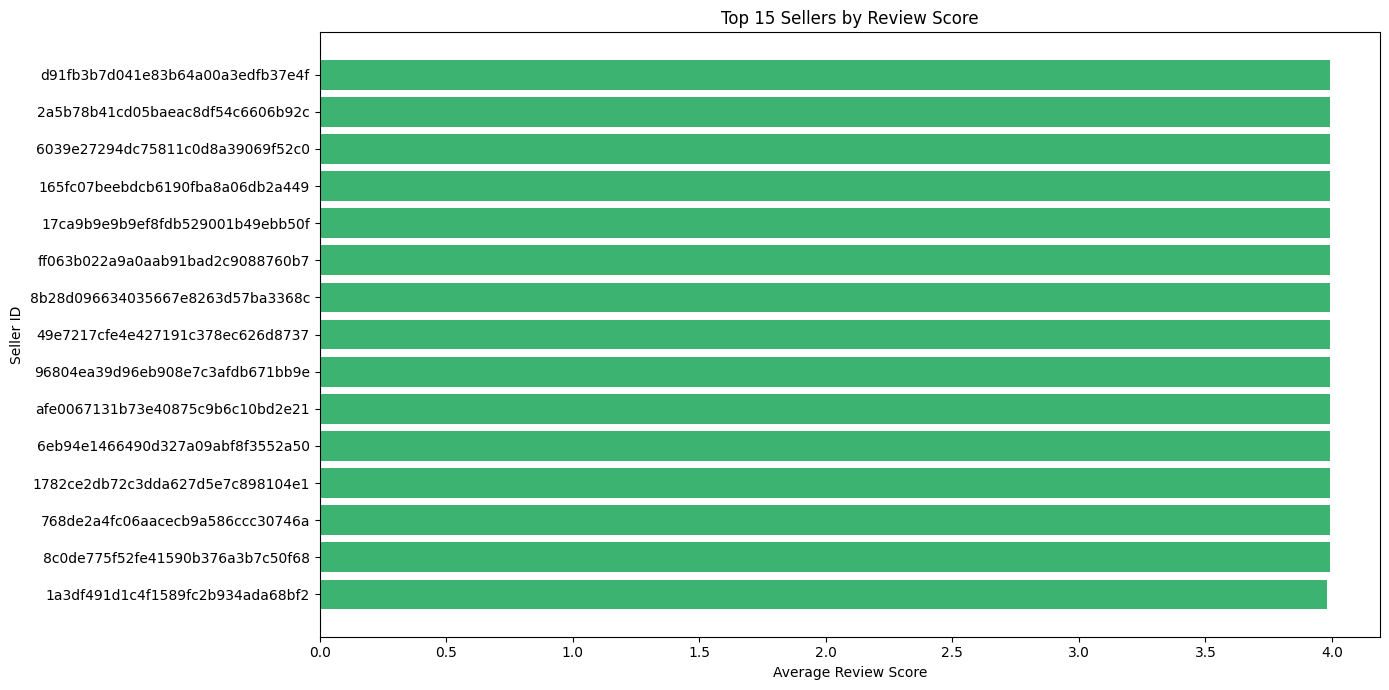

In [ ]:
top_sellers_by_review_score = seller_performance.filter(col("avg_review_score") <= 3.99).orderBy(col("avg_review_score").desc()).limit(15)
top_sellers_review_pd = top_sellers_by_review_score.toPandas()

plt.figure(figsize=(14, 7))
plt.barh(top_sellers_review_pd["seller_id"], top_sellers_review_pd["avg_review_score"], color="mediumseagreen")
plt.xlabel("Average Review Score")
plt.ylabel("Seller ID")
plt.title("Top 15 Sellers by Review Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()